<div style="text-align:center; markdown=1">
<span style="font-size:12pt">Tugas Otomasi Bangunan</span><br>
<span style="font-size:12pt"><b>Prediksi Status Pemadaman Api di Bangunan Berbasis Gelombang Akustika</b></span><br>
Menggunakan Algoritma Adaboost, Random Forest, Gradient Boosting</div>

<span style="font-size:12pt"><b>M. Nadhir Al Ghifary</b></span><br>
<span style="font-size:12pt">22/503570/TK/55030</span><br>

Link Dataset:
https://www.kaggle.com/datasets/muratkokludataset/acoustic-extinguisher-fire-dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta

In [3]:
df = pd.read_excel("Acoustic_Extinguisher_Fire_Dataset.xlsx")

___

### <b>Set Up Eksperimen </b>

Sebuah setup eksperimental dibuat untuk menguji pemadaman api dengan gelombang suara. Beberapa poin penting dalam setup eksperimen
- Setup eksperimental dibuat untuk mengeksplorasi konsep pemadaman api dengan menggunakan gelombang suara.
- Sistem pemadaman api dengan gelombang suara ditempatkan di dalam ruangan api yang terbuat dari bahan tahan api A1 yang non-mudah terbakar.
- Sistem ini terdiri dari kolimator dengan 4 subwoofer yang memiliki total daya sebesar 1000W (masing-masing subwoofer memiliki daya 250W).
- Terdapat juga 2 amplifier yang digunakan untuk memperkuat sinyal audio yang berasal dari generator sinyal. Setiap amplifier terhubung ke 2 subwoofer.
- Saat sistem dihidupkan, sistem mengambil arus tinggi secara instan, sehingga memerlukan pasokan daya khusus yang dirancang khusus.
- Kolimator diciptakan untuk memfokuskan aliran udara yang dihasilkan oleh gelombang suara pada satu titik target.
- Gelombang suara yang dihasilkan oleh getaran subwoofer dikirim melalui lubang berdiameter 13 cm pada kolimator untuk memengaruhi api.
- Kolimator memungkinkan gelombang suara untuk berkembang dari sumber ke target tanpa terdispersi.

<p align = 'center'><img src="https://ars.els-cdn.com/content/image/1-s2.0-S2214157X21007243-gr1_lrg.jpg" alt="Visualisasi Setup" width="600" height="400" /></p>

___

### <b>#1: Telaah Data </b>

#### <b>A. Menampilkan Informasi Dataset</b>

In [4]:
# Menampilkan Informasi Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17442 entries, 0 to 17441
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   SIZE       17442 non-null  int64  
 1   FUEL       17442 non-null  object 
 2   DISTANCE   17442 non-null  int64  
 3   DESIBEL    17442 non-null  int64  
 4   AIRFLOW    17442 non-null  float64
 5   FREQUENCY  17442 non-null  int64  
 6   STATUS     17442 non-null  int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 954.0+ KB


#### <b>B. Menampilkan Dataset</b>

In [5]:
#Menampilkan 5 data awal dataset
df.head(10)

,SIZE,FUEL,DISTANCE,DESIBEL,AIRFLOW,FREQUENCY,STATUS
0,1,gasoline,10,96,0.0,75,0
1,1,gasoline,10,96,0.0,72,1
2,1,gasoline,10,96,2.6,70,1
3,1,gasoline,10,96,3.2,68,1
4,1,gasoline,10,109,4.5,67,1
5,1,gasoline,10,109,7.8,66,1
6,1,gasoline,10,103,9.7,65,1
7,1,gasoline,10,95,12.0,60,1
8,1,gasoline,10,102,13.3,55,1
9,1,gasoline,10,93,15.4,52,1


In [6]:
#Menampilkan 5 data terakhir dataset
df.tail(5)

,SIZE,FUEL,DISTANCE,DESIBEL,AIRFLOW,FREQUENCY,STATUS
17437,7,lpg,190,86,2.2,5,0
17438,7,lpg,190,84,2.0,4,0
17439,7,lpg,190,80,1.5,3,0
17440,7,lpg,190,76,0.4,2,0
17441,7,lpg,190,72,0.0,1,0


Berdasarkan telaah data tersebut, diperlukan perbaikan data sebelum visualiasi dan analisis statistik karena:
- Terdapat satu fitur yaitu `FUEL` yang memiliki tipe data `object`

___

### <b>#2: Perbaikan Data </b>

#### <b>A. Merubah Tipe Variabel dari Object ke Integer</b>

In [7]:
# Membuat dictionary parameter seluruh object agar integer
perubahan = {'gasoline': 1, 
             'thinner': 2,
             'kerosene': 3,
             'lpg': 4}

# Merubah object sesuai dengan dictionary yang dibuat
df['FUEL'] = df['FUEL'].replace(perubahan)

#### <b>B. Menampilkan Ulang Info Datasheet Setelah Perbaikan Tipe Data</b>

In [8]:
# Menampilkan Informasi Singkat dari Dataset setelah perubahan tipe variabel
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17442 entries, 0 to 17441
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   SIZE       17442 non-null  int64  
 1   FUEL       17442 non-null  int64  
 2   DISTANCE   17442 non-null  int64  
 3   DESIBEL    17442 non-null  int64  
 4   AIRFLOW    17442 non-null  float64
 5   FREQUENCY  17442 non-null  int64  
 6   STATUS     17442 non-null  int64  
dtypes: float64(1), int64(6)
memory usage: 954.0 KB


#### <b>B. Menampilkan Ulang Datasheet</b>

In [9]:
# Menampilkan Datasheet Setelah Perubahan
df.head(5)

,SIZE,FUEL,DISTANCE,DESIBEL,AIRFLOW,FREQUENCY,STATUS
0,1,1,10,96,0.0,75,0
1,1,1,10,96,0.0,72,1
2,1,1,10,96,2.6,70,1
3,1,1,10,96,3.2,68,1
4,1,1,10,109,4.5,67,1


Berdasarkan hasil perbaikan data tersebut, data sudah seluruhnya bertipe `numeric` sehingga dapat dianalisis secara statistik

___

### <span style="font-size:14pt"><b>#3: Analisis Statistik Data </b></span>

#### <b>A. Menguji Kekosongan Data</b>

In [10]:
# Menghitung persentase hilang tiap parameter dataset
persentase_datahilang = (df.isnull().sum() / len(df)) * 100

# Menampilkan persentae data hilang tiap parameter dataset
print('Persentase Data Hilang')
persentase_datahilang

Persentase Data Hilang


SIZE         0.0
FUEL         0.0
DISTANCE     0.0
DESIBEL      0.0
AIRFLOW      0.0
FREQUENCY    0.0
STATUS       0.0
dtype: float64

#### <b>B. Deskrispsi Statistik</b>

In [11]:
# Mengeksplorasi data
df.describe()

,SIZE,FUEL,DISTANCE,DESIBEL,AIRFLOW,FREQUENCY,STATUS
count,17442.000000,17442.000000,17442.000000,17442.000000,17442.000000,17442.000000,17442.000000
mean,3.411765,2.235294,100.000000,96.379142,6.975634,31.611111,0.497821
std,1.750977,1.001757,54.773826,8.164096,4.736169,20.939149,0.500010
min,1.000000,1.000000,10.000000,72.000000,0.000000,1.000000,0.000000
25%,2.000000,1.000000,50.000000,90.000000,3.200000,14.000000,0.000000
50%,3.000000,2.000000,100.000000,95.000000,5.800000,27.500000,0.000000
75%,5.000000,3.000000,150.000000,104.000000,11.200000,47.000000,1.000000
max,7.000000,4.000000,190.000000,113.000000,17.000000,75.000000,1.000000


#### <b>C. Korelasi Antar Variabel</b>

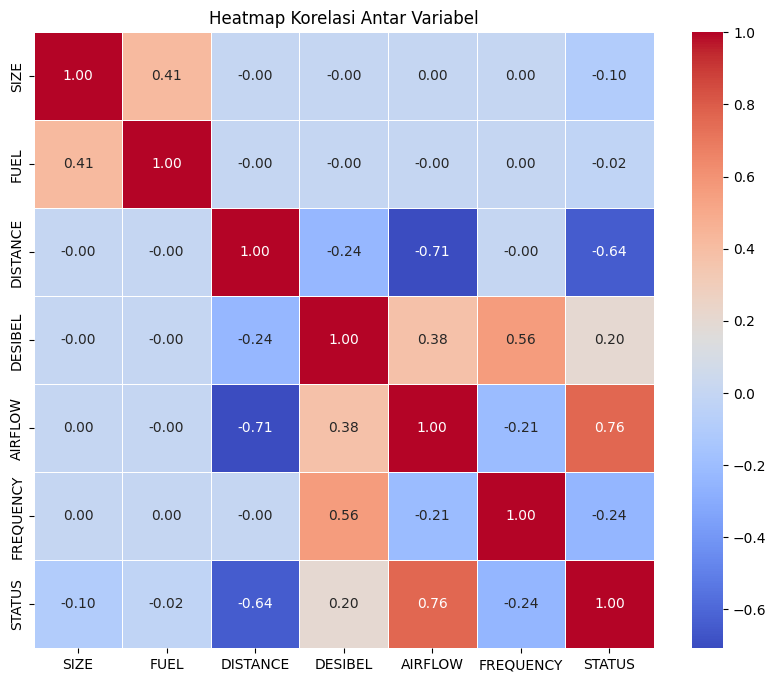

In [12]:
# Hitung matriks korelasi
correlation_matrix = df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))  # Sesuaikan ukuran jika diperlukan
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Heatmap Korelasi Antar Variabel")
plt.show()

___

### <b>#4: Visualisasi Data </b>

#### <b>A. Boxplot Tiap Terukur</b>

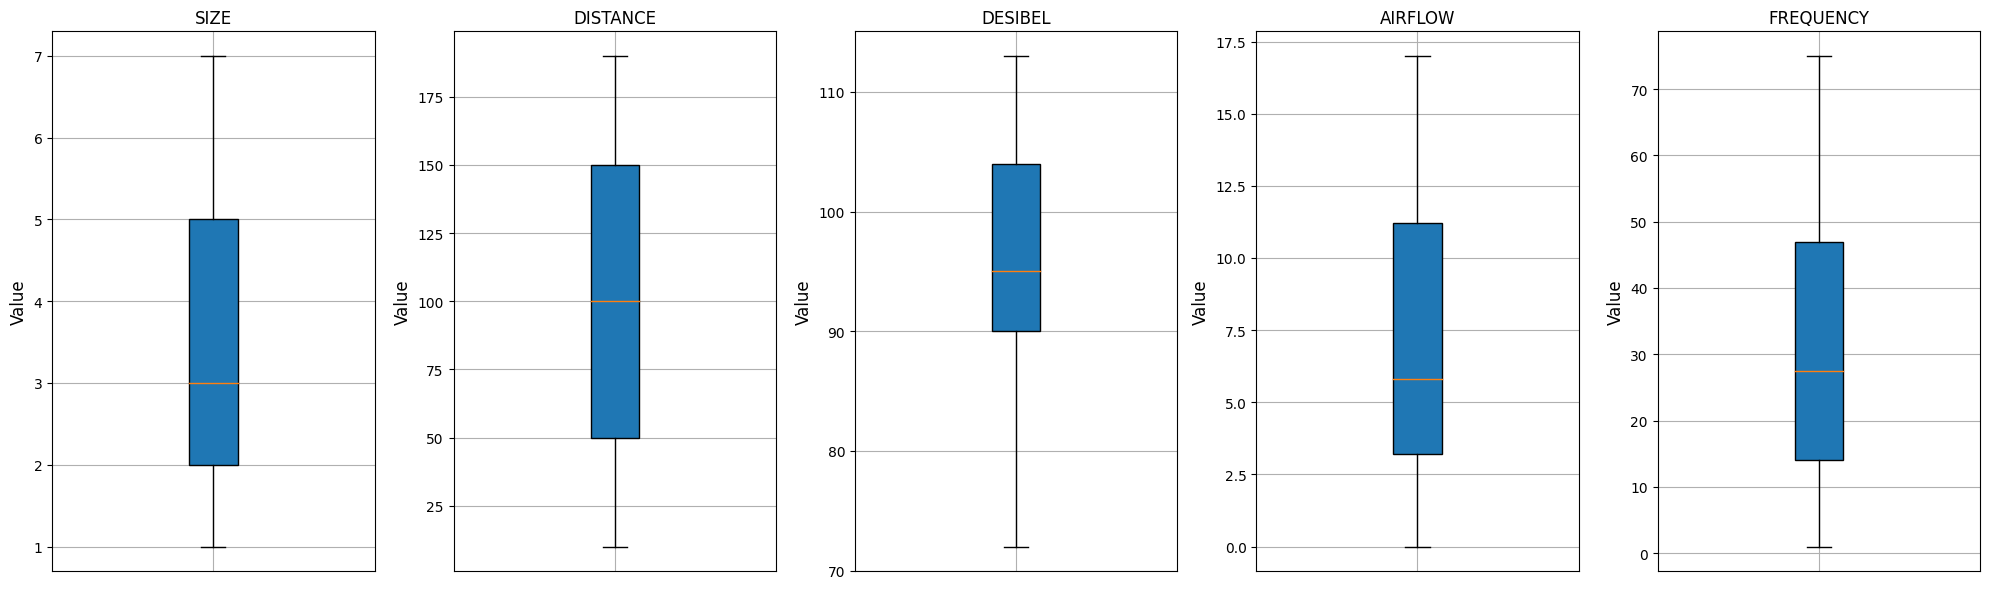

In [13]:
# Tentukan kolom untuk dikecualikan
columns_to_drop = ['FUEL', 'STATUS']

# Filter kolom kecuali yang dikecualikan
columns_to_plot = [col for col in df.columns if col not in columns_to_drop]

# Tentukan layout subplot (6 baris x 4 kolom)
num_cols = 5
num_rows = (len(columns_to_plot) + num_cols - 1) // num_cols  # Hitung jumlah baris yang dibutuhkan

# Buat figure dan axes
fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 6))
axes = axes.flatten()  # Ratakan axes untuk iterasi lebih mudah

# Plot boxplot untuk setiap kolom yang dipilih
for i, col in enumerate(columns_to_plot):
    data = df[col].dropna()  # Hilangkan nilai NaN
    axes[i].boxplot(data, patch_artist=True)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel("Value", fontsize=12)
    axes[i].grid(True)
    axes[i].tick_params(axis="x", which="both", bottom=False, labelbottom=False)  # Hilangkan label x-axis

# Sembunyikan subplot kosong jika ada
for j in range(len(columns_to_plot), len(axes)):
    axes[j].axis('off')

# Atur tata letak subplot
plt.tight_layout()

# Tampilkan plot
plt.show()

Berdasarkan data ini, terlihat data sudah bersih dari outliers

#### <b>B. Histogram Distribusi Jenis Bahan Bakar</b>

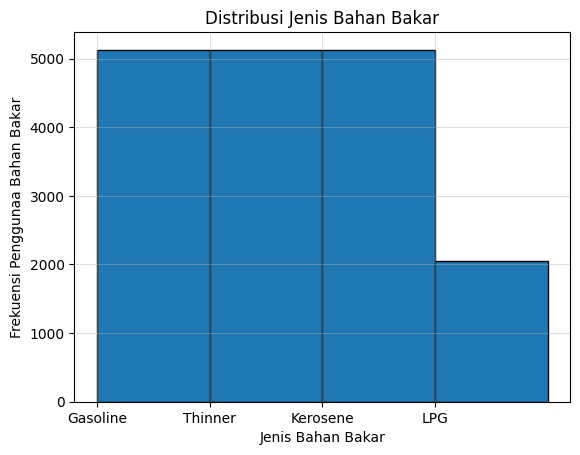

In [ ]:
# Membuat histogram
plt.hist(df['FUEL'], bins=range(1, 6), edgecolor='black')  # Pastikan bins sesuai
plt.title('Distribusi Jenis Bahan Bakar')
plt.xlabel('Jenis Bahan Bakar')
plt.ylabel('Frekuensi Penggunaa Bahan Bakar')

# Mengubah keterangan di sumbu x
plt.xticks(ticks=[1, 2, 3, 4], labels=['Gasoline', 'Thinner', 'Kerosene', 'LPG'])

plt.grid(alpha=0.4)
plt.show()

Berdasarkan histogram tersebut nampak data sudah termasuk seimbang. Gasoline, Thinner, dan Kerosene memiliki data yang sama. Adapun LPG lebih kecil secara kuantitas penggunaannya dari jenis bahan bakar lain 

#### <b>C. Distribusi Status Nyala Api</b>

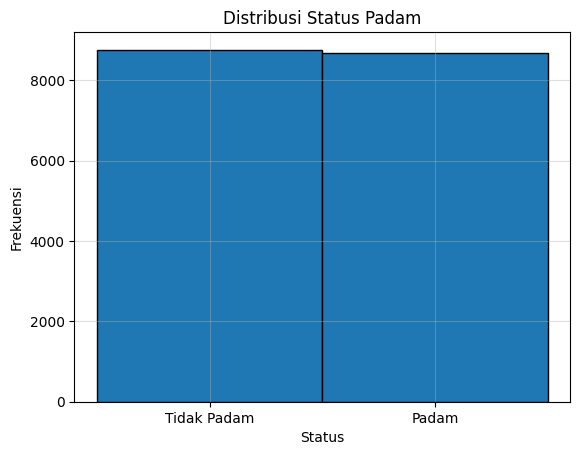

In [15]:
# Membuat histogram
plt.hist(df['STATUS'], bins=[-0.5, 0.5, 1.5], edgecolor='black', align='mid')  # Dua kategori: 0 dan 1
plt.title('Distribusi Status Padam')
plt.xlabel('Status')
plt.ylabel('Frekuensi')

# Mengubah keterangan di sumbu x
plt.xticks(ticks=[0, 1], labels=['Tidak Padam', 'Padam'])

# Menambahkan grid
plt.grid(alpha=0.4)
plt.show()

Berdasarkan distribusi tersebut nampak data yang seimbang antara Padam dan Tidak Padam sehingga sudah siap untuk dimodelkan

___

### <b>#5: Feature Engineering </b>

#### <b>A. Membangi Data Train, Data Test, dan Data Validasi </b>

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeClassifier

# Memisahkan fitur (X) dan target (y)
X = df.drop(columns=['STATUS'])  # Ganti dengan nama kolom target yang tepat
y = df['STATUS']

# Membagi dataset menjadi training dan testing set
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)  # 70% train, 30% lainnya
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)  # 15% val, 15% test

#### <b>B. Feature Importance via Coefficient Ridge Model </b>

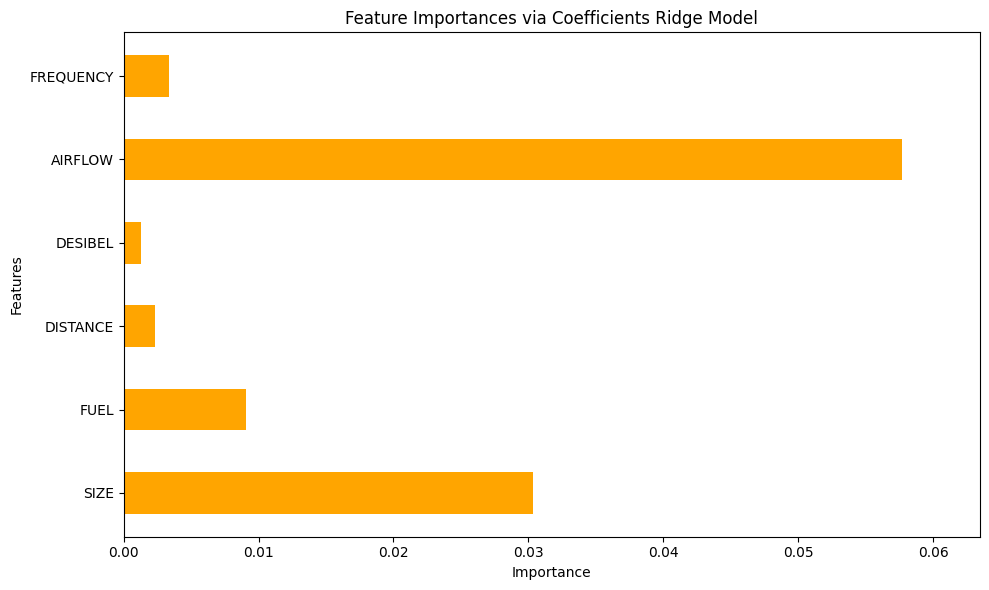

In [17]:
from sklearn.linear_model import RidgeCV

# Model RidgeCV dengan alphas tertentu
ridge = RidgeCV(alphas=np.logspace(-3, 3, num=5)).fit(X_train, y_train)

# Menghitung feature importance berdasarkan absolut nilai koefisien
importance = np.abs(ridge.coef_)

# Nama fitur
if isinstance(X, pd.DataFrame):  # Jika X adalah DataFrame
    feature_names = X.columns
else:  # Jika X adalah array numpy
    feature_names = [f"Feature {i}" for i in range(X.shape[1])]

# Membuat plot dengan bar horizontal
plt.figure(figsize=(10, 6))
plt.barh(y=feature_names, width=importance, color='orange', height=0.5)
plt.title("Feature Importances via Coefficients Ridge Model")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.xlim(0, max(importance) * 1.1)  # Menyesuaikan batas x agar proporsional
plt.tight_layout()
plt.show()

In [18]:
# Memisahkan fitur (X) dan target (y)
X = df.drop(columns=['STATUS'])  # Ganti dengan nama kolom target yang tepat
y = df['STATUS']

___

### <b>#6: Model Building &#8594; Adaboost Classifier - Decission Tree</b>

#### <b>A. Adaboost Classifier - Decission Tree </b>

#### <u> Train Model Metode Train Validation Split</u>

In [36]:
weak_learner = DecisionTreeClassifier(max_leaf_nodes=5)
n_estimators = 100

adaboost_clf = AdaBoostClassifier(
    base_estimator=weak_learner,
    n_estimators=n_estimators,
    algorithm="SAMME",
    random_state=42,
)

adaboost_clf.fit(X_train, y_train)

AdaBoostClassifier(algorithm='SAMME',
                   base_estimator=DecisionTreeClassifier(max_leaf_nodes=5),
                   n_estimators=100, random_state=42)

#### <u> Analisis Konvergensi AdaBoostClassifier</u>

In [20]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

dummy_clf = DummyClassifier()

def misclassification_error(y_true, y_pred):
    return 1 - accuracy_score(y_true, y_pred)

weak_learners_misclassification_error = misclassification_error(
    y_test, weak_learner.fit(X_train, y_train).predict(X_test)
)

dummy_classifiers_misclassification_error = misclassification_error(
    y_test, dummy_clf.fit(X_train, y_train).predict(X_test)
)

print(
    "DecisionTreeClassifier's misclassification_error: "
    f"{weak_learners_misclassification_error:.3f}"
)
print(
    "DummyClassifier's misclassification_error: "
    f"{dummy_classifiers_misclassification_error:.3f}"
)

DecisionTreeClassifier's misclassification_error: 0.135
DummyClassifier's misclassification_error: 0.500


Setelah melatih DecisionTreeClassifiermodel, kesalahan yang dicapai melampaui nilai yang diharapkan yang akan diperoleh dengan menebak label kelas yang paling sering muncul, seperti yang DummyClassifierterjadi.

#### <u> Staged Predict Error untuk Melakukan Boosting Setiap Iterasi Pemodelan</u>

c:\Users\ACER\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


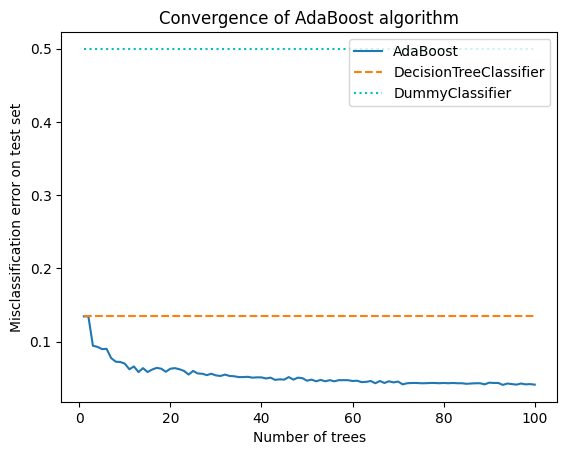

In [25]:
boosting_errors = pd.DataFrame(
    {
        "Number of trees": range(1, n_estimators + 1),
        "AdaBoost": [
            misclassification_error(y_test, y_pred)
            for y_pred in adaboost_clf.staged_predict(X_test)
        ],
    }
).set_index("Number of trees")
ax = boosting_errors.plot()
ax.set_ylabel("Misclassification error on test set")
ax.set_title("Convergence of AdaBoost algorithm")

plt.plot(
    [boosting_errors.index.min(), boosting_errors.index.max()],
    [weak_learners_misclassification_error, weak_learners_misclassification_error],
    color="tab:orange",
    linestyle="dashed",
)
plt.plot(
    [boosting_errors.index.min(), boosting_errors.index.max()],
    [
        dummy_classifiers_misclassification_error,
        dummy_classifiers_misclassification_error,
    ],
    color="c",
    linestyle="dotted",
)
plt.legend(["AdaBoost", "DecisionTreeClassifier", "DummyClassifier"], loc=1)
plt.show()

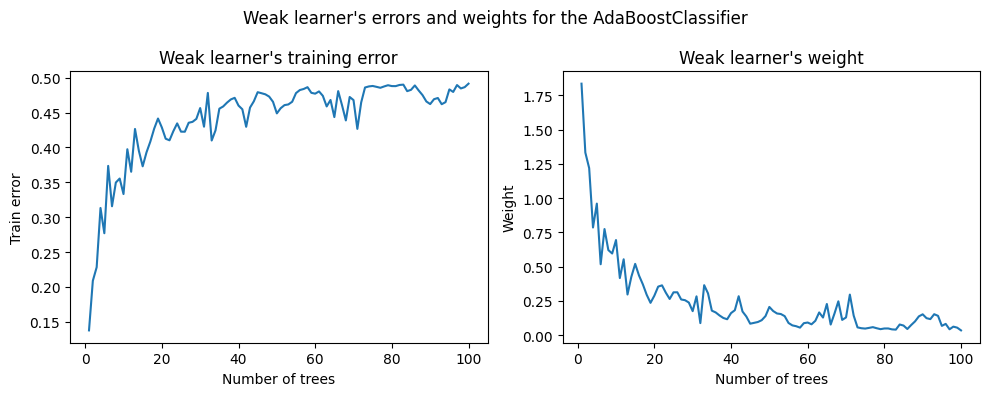

In [22]:
weak_learners_info = pd.DataFrame(
    {
        "Number of trees": range(1, n_estimators + 1),
        "Errors": adaboost_clf.estimator_errors_,
        "Weights": adaboost_clf.estimator_weights_,
    }
).set_index("Number of trees")

axs = weak_learners_info.plot(
    subplots=True, layout=(1, 2), figsize=(10, 4), legend=False, color="tab:blue"
)
axs[0, 0].set_ylabel("Train error")
axs[0, 0].set_title("Weak learner's training error")
axs[0, 1].set_ylabel("Weight")
axs[0, 1].set_title("Weak learner's weight")
fig = axs[0, 0].get_figure()
fig.suptitle("Weak learner's errors and weights for the AdaBoostClassifier")
fig.tight_layout()

#### <b>B. Random Forest Classifier </b>

#### <u> Parameter Pemodelan dan Training</u>

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report

rf_clf = RandomForestClassifier(
    n_estimators=100,      # mirip jumlah estimator AdaBoost
    max_depth=None,        # biarkan pohon full depth (default)
    random_state=42,
    n_jobs=-1              # gunakan semua core CPU agar lebih cepat
)

rf_clf.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

#### <b>C. Gradient Boosting </b>

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report

gb_clf = GradientBoostingClassifier(
    n_estimators=100,     # sama seperti AdaBoost dan Random Forest
    learning_rate=0.1,    # default, biasanya sudah optimal
    max_depth=3,          # sama seperti weak learner tree depth di boosting
    random_state=42
)

gb_clf.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

___

### <b>#7: Evaluasi Model</b>

#### <u> Komparisi Performa Tiap Model</u>

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report

ada_pred = adaboost_clf.predict(X_test)
rf_pred = rf_clf.predict(X_test)
gb_pred = gb_clf.predict(X_test)

def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted"),
        "Recall": recall_score(y_true, y_pred, average="weighted"),
        "F1 Score": f1_score(y_true, y_pred, average="weighted"),
    }

ada_metrics = get_metrics(y_test, ada_pred)
rf_metrics = get_metrics(y_test, rf_pred)
gb_metrics = get_metrics(y_test, gb_pred)

# Visualisasi Classification Report

print("=== AdaBoost Report ===")
print(classification_report(y_test, ada_pred))

print("=== Random Forest Report ===")
print(classification_report(y_test, rf_pred))

print("=== Gradient Boosting Report ===")
print(classification_report(y_test, gb_pred))

=== AdaBoost Report ===
              precision    recall  f1-score   support

           0       0.96      0.95      0.96      1309
           1       0.96      0.96      0.96      1308

    accuracy                           0.96      2617
   macro avg       0.96      0.96      0.96      2617
weighted avg       0.96      0.96      0.96      2617

=== Random Forest Report ===
              precision    recall  f1-score   support

           0       0.97      0.95      0.96      1309
           1       0.96      0.97      0.96      1308

    accuracy                           0.96      2617
   macro avg       0.96      0.96      0.96      2617
weighted avg       0.96      0.96      0.96      2617

=== Gradient Boosting Report ===
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      1309
           1       0.95      0.95      0.95      1308

    accuracy                           0.95      2617
   macro avg       0.95      0.95      0.9

#### <u> Visualisasi Perbandingan Tiap Model</u>

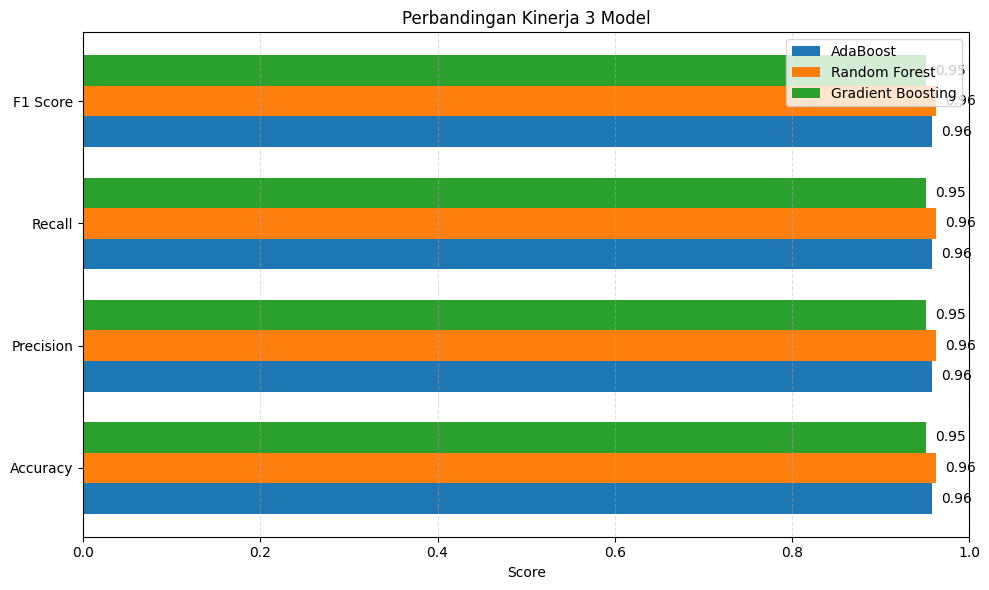

In [35]:
# Grafik Perbandingan (Matplotlib)

labels = list(ada_metrics.keys())  # ['Accuracy', 'Precision', 'Recall', 'F1 Score']

ada_values = list(ada_metrics.values())
rf_values = list(rf_metrics.values())
gb_values = list(gb_metrics.values())

# Membuat posisi Y
y = np.arange(len(labels))
height = 0.25  # ketebalan bar

plt.figure(figsize=(10, 6))

plt.barh(y - height, ada_values, height, label="AdaBoost")
plt.barh(y,        rf_values, height, label="Random Forest")
plt.barh(y + height, gb_values, height, label="Gradient Boosting")

plt.xlim(0, 1)
plt.xlabel("Score")
plt.title("Perbandingan Kinerja 3 Model")
plt.yticks(y, labels)
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.legend()

# Tambahkan nilai pada bar
for i, v in enumerate(ada_values):
    plt.text(v + 0.01, i - height, f"{v:.2f}", va="center")

for i, v in enumerate(rf_values):
    plt.text(v + 0.01, i, f"{v:.2f}", va="center")

for i, v in enumerate(gb_values):
    plt.text(v + 0.01, i + height, f"{v:.2f}", va="center")

plt.tight_layout()
plt.show()